In [1]:
%load_ext autoreload
%autoreload 2

# Librerías

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import KNNImputer
from unidecode import unidecode
from rapidfuzz import process, fuzz
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostRegressor
from sklearn.pipeline import Pipeline
from skopt import BayesSearchCV
from sklearn.base import BaseEstimator, TransformerMixin

# Análisis de datos

In [3]:
df = pd.read_csv('Data/pf_suvs_i302_1s2025.csv')
df = df.drop(df.columns[0], axis=1)
df.info()    
df.describe(include='all')  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18254 entries, 0 to 18253
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Marca                    18254 non-null  object 
 1   Modelo                   18254 non-null  object 
 2   Año                      18254 non-null  float64
 3   Versión                  18254 non-null  object 
 4   Color                    17865 non-null  object 
 5   Tipo de combustible      18254 non-null  object 
 6   Puertas                  18254 non-null  float64
 7   Transmisión              18239 non-null  object 
 8   Motor                    18216 non-null  object 
 9   Tipo de carrocería       18254 non-null  object 
 10  Con cámara de retroceso  4691 non-null   object 
 11  Kilómetros               18254 non-null  object 
 12  Título                   18254 non-null  object 
 13  Precio                   18254 non-null  float64
 14  Moneda                

,Marca,Modelo,Año,Versión,Color,Tipo de combustible,Puertas,Transmisión,Motor,Tipo de carrocería,Con cámara de retroceso,Kilómetros,Título,Precio,Moneda,Descripción,Tipo de vendedor
count,18254,18254,18254.000000,18254,17865,18254,18254.000000,18239,18216,18254,4691,18254,18254,1.825400e+04,18254,18254,18254
unique,47,137,NaN,2072,70,8,NaN,4,271,1,2,2175,2220,NaN,2,12142,3
top,Ford,Ecosport,NaN,1.6 Exclusive Cvt,Gris,Nafta,NaN,Automática,1.6,SUV,Sí,0.0,Nissan Kicks 1.6 Exclusive Cvt,NaN,$,El vendedor no incluyó una descripción del pro...,concesionaria
freq,2161,1569,NaN,320,5468,16067,NaN,12281,4132,18254,3731,4237,320,NaN,11158,2260,8509
mean,NaN,NaN,2042.796209,NaN,NaN,NaN,18.167306,NaN,NaN,NaN,NaN,NaN,NaN,1.760162e+07,NaN,NaN,NaN
std,NaN,NaN,3217.260996,NaN,NaN,NaN,891.766121,NaN,NaN,NaN,NaN,NaN,NaN,1.720810e+07,NaN,NaN,NaN
min,NaN,NaN,1981.000000,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.110000e+02,NaN,NaN,NaN
25%,NaN,NaN,2016.000000,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,3.190000e+04,NaN,NaN,NaN
50%,NaN,NaN,2019.000000,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.720000e+07,NaN,NaN,NaN
75%,NaN,NaN,2024.000000,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.995000e+07,NaN,NaN,NaN


correcciones básicas del dataset:

In [4]:
mask = df['Moneda'] == '$'
df.loc[mask, 'Precio'] = df.loc[mask, 'Precio'] / 1185
df.drop(columns=['Moneda'], inplace=True)
df.drop(columns = ['Tipo de carrocería'],inplace=True)
idx = df[df['Año'] == 436694.0].index
df.drop(idx, inplace=True)
df['Puertas'] = df['Puertas'].replace(60252.0, np.nan)


In [5]:
df.isnull().sum()     

Marca                          0
Modelo                         0
Año                            0
Versión                        0
Color                        389
Tipo de combustible            0
Puertas                        4
Transmisión                   15
Motor                         38
Con cámara de retroceso    13562
Kilómetros                     0
Título                         0
Precio                         0
Descripción                    0
Tipo de vendedor               0
dtype: int64

# distribución de años 

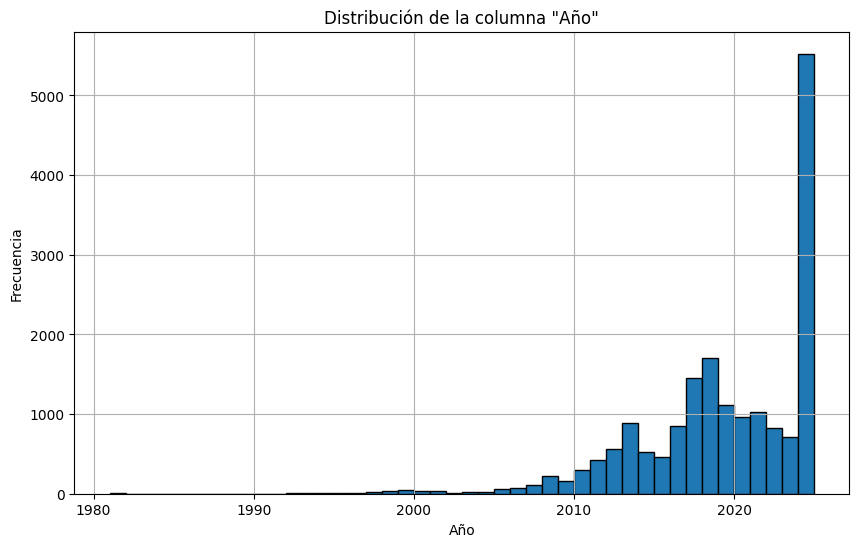

In [6]:
plt.figure(figsize=(10, 6))
plt.hist(df["Año"], bins=44, edgecolor='black')
plt.title(f'Distribución de la columna "{"Año"}"')
plt.xlabel("Año")
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

# distribución de precios

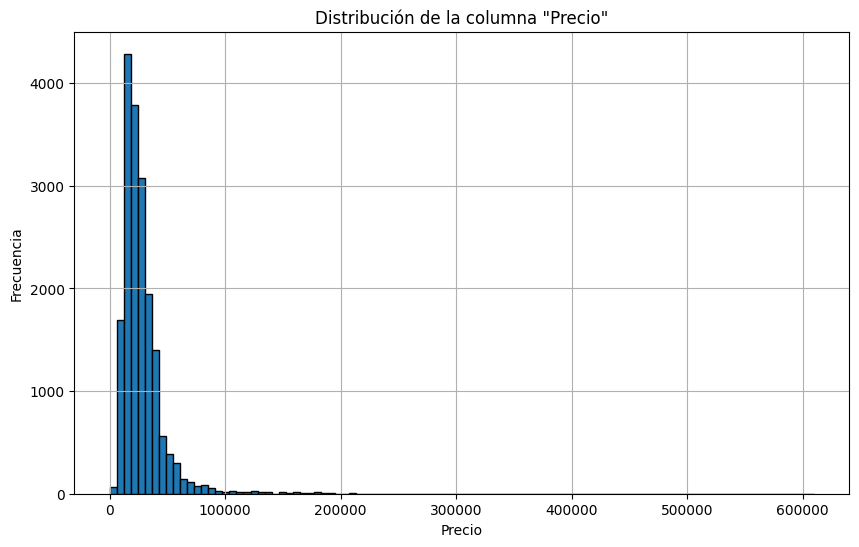

In [7]:
plt.figure(figsize=(10, 6))
plt.hist(df["Precio"], bins=100, edgecolor='black')
plt.title(f'Distribución de la columna "{"Precio"}"')
plt.xlabel("Precio")
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

In [8]:
df["Precio"].describe()  

count     18253.000000
mean      27598.044551
std       20297.864206
min         100.421941
25%       16033.755274
50%       23500.000000
75%       32489.450633
max      610000.000000
Name: Precio, dtype: float64

In [9]:
mappings = {
    'Con cámara de retroceso': {'No': 0, 'Sí': 1},
    'Transmisión': {
        'Automática': 0,
        'Manual': 1,
        'Automática secuencial': 2,
        'Semiautomática': 3
    }
}

for col, mapping in mappings.items():
    code_col = col.replace(' ', '_') + '_code'
    df[code_col] = df[col].map(mapping)



In [10]:
def normalize(text):
    return unidecode(text).lower().strip()

df['color_norm'] = df['Color'].astype(str).apply(normalize)

canonical = [
    'Blanco','Negro','Gris','Azul','Rojo','Verde','Amarillo',
    'Naranja','Celeste','Bordo','Marrón','Violeta','Rosa',
    'Plateado','Dorado','otro','cafe'
]
canonical_lower = [c.lower() for c in canonical]

overrides = {
    'cafe':                         'cafe',
    'blanco nacre tricapa':         'Blanco',
    'steel_blue':                   'Azul',
    'gris selenium':                'Gris',
    'summit white':                 'Blanco',
    'mineralweiss metallic':        'Gris',
    'skyscraper grau metallic':     'Gris',
    'granite crysta bc':            'Gris',
    'prata bari+tet vulc':          'Plateado',
    'champaing':                    'Dorado',
    'noir perla nera':              'Negro',
    'black meet kettle':            'Negro',
    'granite crystal bc':           'Gris',
    'blue':                         'Azul',
    'beige techo negro':            'Marrón',
    'rojo sunset metalizado':       'Rojo',
    'gris artense':                 'Gris',
    'moundaz':                      'otro',
    'blanco banchisa bicolor negro':'Blanco'
}

def map_color(name):
    if name in overrides:
        return overrides[name]
    match, score, _ = process.extractOne(name, canonical_lower, scorer=fuzz.token_sort_ratio)
    if score >= 40:
        return canonical[canonical_lower.index(match)]
    return None

df['color_estandar'] = df['color_norm'].apply(map_color)
print( df['color_estandar'].value_counts(dropna=False))
df['Color']=df['color_estandar']
df.drop(columns=['color_estandar','color_norm'], inplace=True)

color_estandar
Gris        5531
Blanco      4827
Negro       2961
Plateado    1438
Azul        1126
Rojo        1119
Naranja      462
Marrón       258
Dorado       193
Verde        138
Celeste       94
Violeta       33
Bordo         29
Amarillo      25
otro           8
Rosa           8
cafe           3
Name: count, dtype: int64


In [11]:
canonical_brands = [
    'Ford','Volkswagen','Jeep','Chevrolet','Renault','Toyota','Peugeot','Nissan',
    'Citroën','BMW','Honda','Hyundai','Audi','Fiat','Chery','Kia',
    'Mercedes-Benz','Dodge','BAIC','Suzuki','Land Rover','Porsche',
    'Mitsubishi','Volvo','SsangYong','D.S.','Alfa Romeo','JAC','Jetour',
    'Haval','GWM','Lifan','Lexus','Isuzu','Subaru','Daihatsu','Mini','otro'
]
canonical_lower = [c.lower() for c in canonical_brands]

overrides = {
    'rrenault':               'Renault',
    'hiunday':                'Hyundai',
    'vol':                    'Volvo',
    'range rover':            'Land Rover',
    'ds automobiles':         'D.S.',
    'd.s':                    'D.S.',
    'd·s':                    'D.S.',
}
def map_brand(name):
    if name in overrides:
        return overrides[name]
    match, score, _ = process.extractOne(name, canonical_lower, scorer=fuzz.token_sort_ratio)
    if score >= 80:
        return canonical_brands[canonical_lower.index(match)]
    return 'otro'

df['brand_norm'] = df['Marca'].apply(normalize)
df['Marca_limpia'] = df['brand_norm'].apply(map_brand)

df['Marca'] = df['Marca_limpia']

df.drop(columns=['brand_norm','Marca_limpia'], inplace=True)

print(df['Marca'].value_counts(dropna=False))

df['modelo_norm'] = df['Modelo'].apply(normalize)

overrides_model = {
    'sw4':        'hilux sw4',
    'hilux sw4': 'hilux sw4',
    'x55':       'x5',
    'q5 sportback': 'q5 sportback',
    'q3 sportback': 'q3 sportback',
    'grand santa fe': 'santa fe'
}

df['modelo_final'] = df['modelo_norm'].map(lambda x: overrides_model.get(x, x))
df['Modelo'] = df['modelo_final']
df.drop(columns=['modelo_final','modelo_norm'], inplace=True)
print(df['Modelo'].value_counts())

Marca
Ford             2161
Jeep             2049
Volkswagen       2037
Chevrolet        1750
Renault          1492
Toyota           1260
Peugeot          1250
Nissan           1059
Citroën           721
BMW               672
Honda             597
Hyundai           571
Audi              529
Fiat              366
Chery             344
Kia               290
Mercedes-Benz     282
Dodge             185
BAIC              165
Suzuki             76
Porsche            67
Land Rover         66
Mitsubishi         47
Volvo              39
SsangYong          30
D.S.               29
Alfa Romeo         25
JAC                19
Jetour             15
Haval               9
GWM                 9
otro                8
Isuzu               8
Lifan               7
Lexus               7
Subaru              5
Daihatsu            4
Mini                3
Name: count, dtype: int64
Modelo
ecosport    1569
tracker     1511
2008        1144
duster      1048
compass      916
            ... 
samurai        2
sander

In [12]:
df['Kilómetros'] = (
    df['Kilómetros']
    .str.replace(r'\s*km$', '', regex=True)
    .str.replace(r'\.', '', regex=True)
    .astype(float)
)

In [13]:
from sklearn.model_selection import train_test_split

# Primero: dev vs test
dev_df, test_df = train_test_split(
    df,
    test_size=0.2,        
    random_state=42,     
    shuffle=True
)

# Segundo: train vs val 
train_df, val_df = train_test_split(
    dev_df,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

eliminacion de outliers

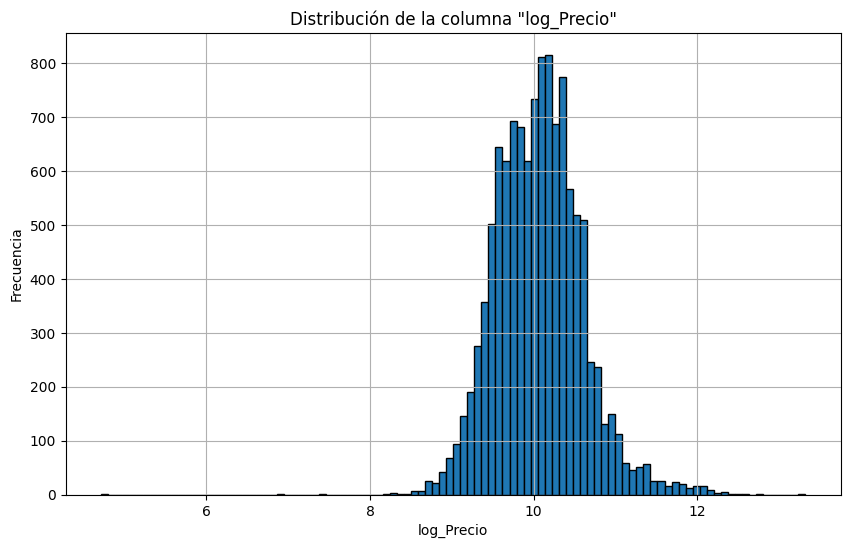

Número de outliers: 120


In [14]:
train_df["log_Precio"] = np.log(train_df["Precio"])
val_df["log_Precio"] = np.log(val_df["Precio"])
test_df["log_Precio"] = np.log(test_df["Precio"])
plt.figure(figsize=(10, 6))
plt.hist(train_df["log_Precio"], bins=100, edgecolor='black')
plt.title(f'Distribución de la columna "{"log_Precio"}"')
plt.xlabel("log_Precio")
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

mu = train_df["log_Precio"].mean()
sigma = train_df["log_Precio"].std()

outliers = train_df[np.abs(train_df["log_Precio"] - mu) > 3 * sigma]
print(f"Número de outliers: {len(outliers)}")

train_df= train_df[np.abs(train_df["log_Precio"] - mu) <= 3 * sigma].copy()
train_df["Precio"] = np.exp(train_df["log_Precio"])

val_df= val_df[np.abs(val_df["log_Precio"] - mu) <= 3 * sigma].copy()
val_df["Precio"] = np.exp(val_df["log_Precio"])

test_df= test_df[np.abs(test_df["log_Precio"] - mu) <= 3 * sigma].copy()
test_df["Precio"] = np.exp(test_df["log_Precio"])



generacion de muestras 

In [ ]:
autos_viejos = train_df[train_df['Año'] <= 2010].copy()

def perturbar(auto):
    nuevo = auto.copy()

    # Modificaciones 
    nuevo['Kilómetros'] *= np.random.normal(1.1, 0.1)        # +10% km aprox
    nuevo['Precio'] *= np.random.normal(0.95, 0.05)          # pequeño ajuste en precio
    nuevo['Con cámara de retroceso'] = np.random.choice(['Sí', 'No'], p=[0.4, 0.6])
    nuevo['Tipo de vendedor'] = np.random.choice(['Particular', 'Concesionaria'])
    nuevo['Color'] = auto['Color'] if np.random.rand() > 0.1 else np.random.choice(train_df['Color'].unique())

    return nuevo

aumentados = []

for i in range(3):  
    aumentados.append(autos_viejos.apply(perturbar, axis=1))

train_df = pd.concat([train_df] + aumentados, ignore_index=True)


In [16]:
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

train_df[['Modelo_code', 'Version_code']] = encoder.fit_transform(train_df[['Modelo', 'Versión']])
val_df[['Modelo_code', 'Version_code']] = encoder.transform(val_df[['Modelo', 'Versión']])
test_df[['Modelo_code', 'Version_code']] = encoder.transform(test_df[['Modelo', 'Versión']])


In [17]:
cols_to_impute = ['Modelo_code', 'Año', 'Version_code'] + [c.replace(' ', '_') + '_code' for c in mappings]

# Ajustar e imputar en train
imputer = KNNImputer(n_neighbors=5)
train_df[cols_to_impute] = imputer.fit_transform(train_df[cols_to_impute])

# Transformar val y test con el mismo imputador
val_df[cols_to_impute] = imputer.transform(val_df[cols_to_impute])
test_df[cols_to_impute] = imputer.transform(test_df[cols_to_impute])


In [18]:
for col, mapping in mappings.items():
    code_col = col.replace(' ', '_') + '_code'
    inv_map = {v: k for k, v in mapping.items()}
    for df_ in [train_df, val_df, test_df]:
        df_[code_col] = np.round(df_[code_col]).astype(int)
        df_[col] = df_[code_col].map(inv_map)


In [ ]:
train_df['Puertas'] = train_df['Puertas'].replace(60252.0, np.nan)
puertas_cols = ['Modelo_code', 'Año', 'Version_code', 'Puertas']


imputer_puertas = KNNImputer(n_neighbors=5)
train_df[puertas_cols] = imputer_puertas.fit_transform(train_df[puertas_cols])
val_df[puertas_cols] = imputer_puertas.transform(val_df[puertas_cols])
test_df[puertas_cols] = imputer_puertas.transform(test_df[puertas_cols])


for df_ in [train_df, val_df, test_df]:
    df_['Puertas'] = np.round(df_['Puertas']).astype(int)


In [20]:
class IncrementalFreqEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols, alpha=1.0, bucket_other=True):
        self.cols         = cols
        self.alpha        = alpha
        self.bucket_other = bucket_other

    def fit(self, X, y=None):
        self.N_      = len(X)
        self.counts_ = {col: X[col].value_counts().to_dict()
                        for col in self.cols}
        self.K_ = {col: len(self.counts_[col]) for col in self.cols}
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.cols:
            cnts = self.counts_[col]
            N    = self.N_
            K    = self.K_[col]
            α    = self.alpha

            freq_map = {cat: (cnt + α) / (N + α * K)
                        for cat, cnt in cnts.items()}
            default = α / (N + α * K)

            if self.bucket_other:
                known = set(cnts.keys())
                X[col] = X[col].where(X[col].isin(known), 'Other')
                freq_map['Other'] = default

            X[col + '_freq'] = X[col].map(freq_map).fillna(default)

        return X

    def partial_fit(self, X, y=None):
        """
        (Opcional) incorporar X a tu histórico:
        suma conteos y actualiza N_, K_, counts_
        """
        for col in self.cols:
            new_counts = X[col].value_counts().to_dict()
            for cat, cnt in new_counts.items():
                self.counts_[col][cat] = self.counts_[col].get(cat, 0) + cnt
            self.K_[col] = len(self.counts_[col])
        self.N_ += len(X)
        return self

# feature engineering

In [21]:
train_df['Edad']= 2026 - train_df['Año']
train_df['log_km'] = np.log1p(train_df['Kilómetros'])
train_df['km_per_year'] = train_df['Kilómetros'] / (train_df['Edad'])

val_df['Edad']= 2026 - val_df['Año']
val_df['log_km'] = np.log1p(val_df['Kilómetros'])
val_df['km_per_year'] = val_df['Kilómetros'] / (val_df['Edad'])

test_df['Edad']= 2026 - test_df['Año']
test_df['log_km'] = np.log1p(test_df['Kilómetros'])
test_df['km_per_year'] = test_df['Kilómetros'] / (test_df['Edad'])



Categorías nuevas en test: {'Marca': np.int64(5), 'Modelo': np.int64(8), 'Versión': np.int64(257), 'Color': np.int64(0), 'Tipo de combustible': np.int64(1), 'Transmisión': np.int64(0), 'Motor': np.int64(41), 'Con cámara de retroceso': np.int64(0), 'Título': np.int64(290), 'Descripción': np.int64(2282), 'Tipo de vendedor': np.int64(0), 'log_Precio': np.int64(383), 'km_per_year': np.int64(473)}


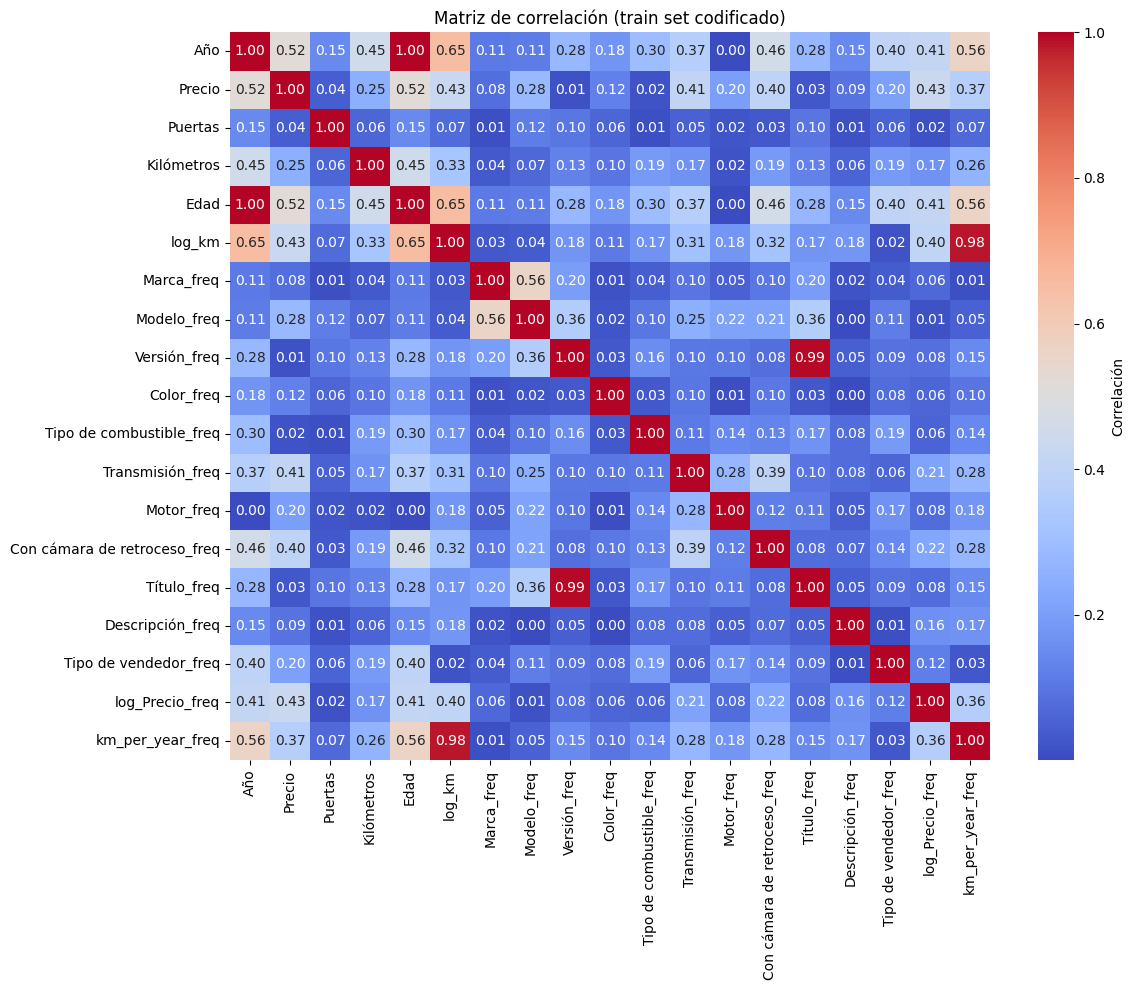

In [ ]:
aux_cols = ['Modelo_code', 'Version_code'] + [c.replace(' ', '_') + '_code' for c in mappings]
for df_ in [train_df, val_df, test_df]:
    for col in aux_cols:
        if col in df_.columns:
            df_.drop(columns=col, inplace=True)

exclude = ['Año', 'Precio', 'Puertas', 'Kilómetros', 'Edad', 'log_km']
categoricals = [c for c in train_df.columns if c not in exclude]

enc = IncrementalFreqEncoder(
    cols=categoricals,
    alpha=5.0,
    bucket_other=True
)

# Fit solo con train (sin leakage)
enc.fit(train_df)

unknown_counts = {}
for col in categoricals:
    known = set(enc.counts_[col].keys())
    mask = ~test_df[col].isin(known)
    unknown_counts[col] = mask.sum()

print("Categorías nuevas en test:", unknown_counts)


train_enc = enc.transform(train_df)
val_enc   = enc.transform(val_df)
test_enc  = enc.transform(test_df)

numeric_cols = ['Año', 'Precio', 'Puertas', 'Kilómetros', 'Edad', 'log_km']
freq_feats = [col + '_freq' for col in categoricals]

df_corr = train_enc[numeric_cols + freq_feats]


corr_matrix = df_corr.corr(method='pearson').abs()

plt.figure(figsize=(12,10))
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f",
    cmap="coolwarm",
    cbar_kws={'label':'Correlación'}
)
plt.title("Matriz de correlación (train set codificado)")
plt.tight_layout()
plt.show()


# Preparacion para train

In [23]:
freq_feats.remove('Título_freq')
freq_feats.remove('Descripción_freq')


train_enc.drop(columns=['Título_freq', 'Descripción_freq'], inplace=True)
val_enc.drop(columns=['Título_freq', 'Descripción_freq'], inplace=True)
test_enc.drop(columns=['Título_freq', 'Descripción_freq'], inplace=True)

df.to_csv('Data/pf_suvs_i302_1s2025_processed.csv', index=False,sep=',')  

numerical = ['Año', 'Puertas', 'Kilómetros','Edad', 'log_km']
features  = numerical + freq_feats

X_train = train_enc[features]
X_val  = val_enc[features]
X_test = test_enc[features]
y_train = np.log(train_enc['Precio'])
y_val  = np.log(val_enc['Precio'])
y_test = np.log(val_enc['Precio'])

# Ridge 

In [24]:
alphas = np.logspace(-3, 1, 13)
ridge_pipeline = make_pipeline(
    StandardScaler(),
    RidgeCV(
        alphas=alphas,
        scoring='neg_root_mean_squared_error',
        cv=5
    )
)

ridge_pipeline.fit(X_train, y_train)

best_alpha = ridge_pipeline.named_steps['ridgecv'].alpha_
print("Mejor α (λ) según CV:", best_alpha)

y_pred_log = ridge_pipeline.predict(X_val)

y_val_orig = np.exp(y_val)
y_pred_orig = np.exp(y_pred_log)

rmse_val = np.sqrt(mean_squared_error(y_val_orig, y_pred_orig))
r2_val   = r2_score(y_val_orig, y_pred_orig)
print(f"Val RMSE (USD): {rmse_val:,.0f}")
print(f"Val R² :   {r2_val:.3f}")

Mejor α (λ) según CV: 10.0
Val RMSE (USD): 11,051
Val R² :   0.442


# Gradient Boosting

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores parámetros GBR: {'subsample': 1.0, 'n_estimators': 500, 'min_samples_leaf': 20, 'max_depth': 5, 'learning_rate': 0.1}
GBR Va; RMSE (USD): 4,289
GBR Val R²      :   0.916


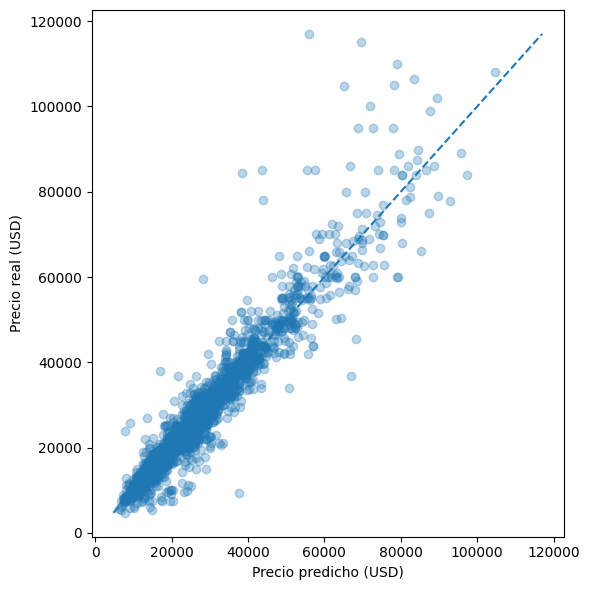

In [25]:
gbr = GradientBoostingRegressor(random_state=0)
param_dist = {
    'n_estimators':    [100, 300, 500],
    'learning_rate':   [0.01, 0.05, 0.1],
    'max_depth':       [3, 5, 7],
    'min_samples_leaf':[20, 50, 100],
    'subsample':       [0.8, 1.0]
}
search = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    random_state=0,
    verbose=1
)
search.fit(X_train, y_train)

best_gbr   = search.best_estimator_
y_pred_log = best_gbr.predict(X_val)

y_val_orig = np.exp(y_val)
y_pred_orig = np.exp(y_pred_log)

rmse_val = np.sqrt(mean_squared_error(y_val_orig, y_pred_orig))
r2_val   = r2_score(y_val_orig, y_pred_orig)
print("Mejores parámetros GBR:", search.best_params_)
print(f"GBR Va; RMSE (USD): {rmse_val:,.0f}")
print(f"GBR Val R²      :   {r2_val:.3f}")

plt.figure(figsize=(6,6))
plt.scatter(y_pred_orig, y_val_orig, alpha=0.3)
mn, mx = y_val_orig.min(), y_val_orig.max()
plt.plot([mn, mx], [mn, mx], ls='--')
plt.xlabel("Precio predicho (USD)")
plt.ylabel("Precio real (USD)")
plt.tight_layout()
plt.show()

# Catboost

In [26]:
pipe_cb = Pipeline([
    ('scaler', StandardScaler()),
    ('cb', CatBoostRegressor(
        random_seed=0,
        verbose=0,
        early_stopping_rounds=50,
        eval_metric='RMSE',
        allow_writing_files=False
    ))
])

search_spaces = {
    'cb__iterations':       (500, 2000),
    'cb__learning_rate':    (1e-3, 0.3, 'log-uniform'),
    'cb__depth':            (4, 12),
    'cb__l2_leaf_reg':      (1, 20),
    'cb__bagging_temperature': (0.0, 1.0),
    'cb__border_count':     (32, 255),
    'cb__subsample':        (0.6, 1.0)
}

opt = BayesSearchCV(
    estimator=pipe_cb,
    search_spaces=search_spaces,
    n_iter=10,                                
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

opt.fit(X_train, y_train)

print("Mejores parámetros CatBoost (BayesSearch):")
print(opt.best_params_)

y_pred_log_cb = opt.predict(X_val)
y_true = np.exp(y_val)
y_pred = np.exp(y_pred_log_cb)

rmse_cb = np.sqrt(mean_squared_error(y_true, y_pred))
r2_cb   = r2_score(y_true, y_pred)

print(f"CatBoost Val RMSE (USD): {rmse_cb:,.0f}")
print(f"CatBoost Val R²:   {r2_cb:.3f}")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Mejores parámetros CatBoost (BayesSearch):
OrderedDict([('cb__bagging_temperature', 0.7995534416071731), ('cb__border_count', 130), ('cb__depth', 8), ('cb__iterations', 1574), ('cb__l2_leaf_reg', 18), ('cb__learning_rate', 0.05972733054818639), ('cb__subsample', 0.7696712289842729)])
CatBoost Val RMSE (USD): 4,331
CatBoost Val R²:   0.914
